In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Đọc file CSV
file_path = "/home/huy/Smart_Construction/data/20250815_sensor_data.csv"  # đổi đường dẫn nếu cần
df = pd.read_csv(file_path)

# Xem 5 dòng đầu
df.head()

,_id,mac,Accel_x,Accel_y,Accel_z,Gyro_x,Gyro_y,Gyro_z,Timestamp,updated_at,created_at,__v,Timestamp_local,Timestamp_vn,acc_norm,gyro_norm
0,44ef9fda5a14a63dfba92444,ffff00000000,3.44,0.13,-8.99,-1.50,16.79,0.90,2025-08-15 00:00:00.000000+00:00,2025-08-15T00:00:00.000Z,2025-08-15 00:00:00.000000+00:00,0,2025-08-15 07:00:00.000000+07:00,2025-08-15 07:00:00.000000,9.63,16.88
1,c9cc4dd329651b4d47c1753a,ffff00000000,4.93,0.33,-7.98,-0.35,-0.69,28.33,2025-08-15 00:00:01.000000+00:00,2025-08-15T00:00:01.000Z,2025-08-15 00:00:01.000000+00:00,0,2025-08-15 07:00:01.000000+07:00,2025-08-15 07:00:01.000000,9.39,28.34
2,18a556f0b0eb97679de16c49,ffff00000000,2.62,-0.22,-9.58,64.99,-0.67,0.88,2025-08-15 00:00:02.000000+00:00,2025-08-15T00:00:02.000Z,2025-08-15 00:00:02.000000+00:00,0,2025-08-15 07:00:02.000000+07:00,2025-08-15 07:00:02.000000,9.93,65.00
3,766b4e9c5e012adfa3f5ad1a,ffff00000000,0.32,0.66,-8.62,-0.87,14.78,0.35,2025-08-15 00:00:03.000000+00:00,2025-08-15T00:00:03.000Z,2025-08-15 00:00:03.000000+00:00,0,2025-08-15 07:00:03.000000+07:00,2025-08-15 07:00:03.000000,8.65,14.81
4,3f1403e1cccf6e5edb8be5bd,ffff00000000,2.82,0.45,-10.61,-0.30,20.94,1.11,2025-08-15 00:00:04.000000+00:00,2025-08-15T00:00:04.000Z,2025-08-15 00:00:04.000000+00:00,0,2025-08-15 07:00:04.000000+07:00,2025-08-15 07:00:04.000000,10.99,20.97


In [5]:
# Ép kiểu thời gian (dùng Timestamp_vn cho dễ nhìn)
df["Timestamp_vn"] = pd.to_datetime(df["Timestamp_vn"])
df = df.sort_values("Timestamp_vn")

# Đặt Timestamp_vn làm index cho tiện vẽ
df = df.set_index("Timestamp_vn")

# Thông tin nhanh về dữ liệu
df.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 21600 entries, 2025-08-15 07:00:00 to 2025-08-15 16:59:59
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   _id              21600 non-null  object 
 1   mac              21600 non-null  object 
 2   Accel_x          21600 non-null  float64
 3   Accel_y          21600 non-null  float64
 4   Accel_z          21600 non-null  float64
 5   Gyro_x           21600 non-null  float64
 6   Gyro_y           21600 non-null  float64
 7   Gyro_z           21600 non-null  float64
 8   Timestamp        21600 non-null  object 
 9   updated_at       21600 non-null  object 
 10  created_at       21600 non-null  object 
 11  __v              21600 non-null  int64  
 12  Timestamp_local  21600 non-null  object 
 13  acc_norm         21600 non-null  float64
 14  gyro_norm        21600 non-null  float64
dtypes: float64(8), int64(1), object(6)
memory usage: 2.6+ MB


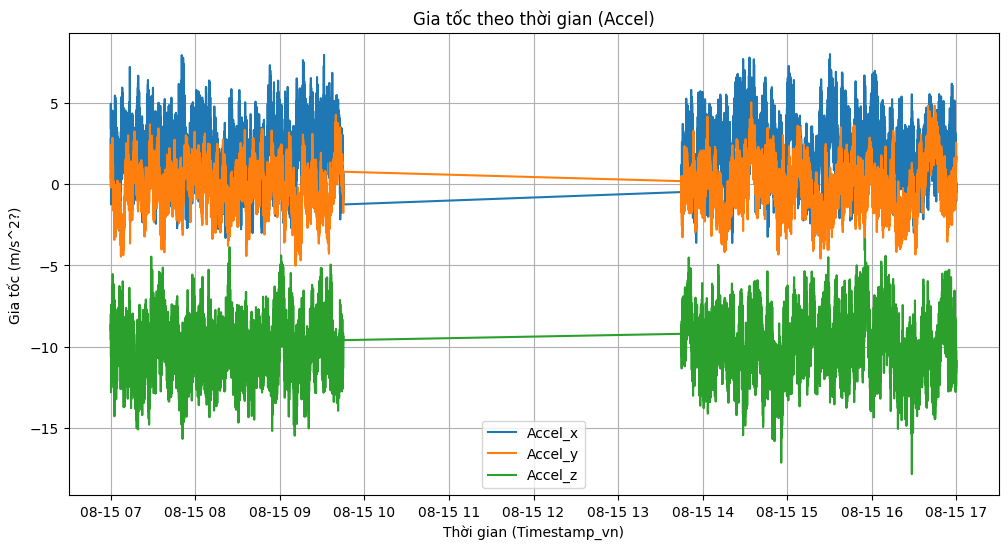

In [6]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["Accel_x"], label="Accel_x")
plt.plot(df.index, df["Accel_y"], label="Accel_y")
plt.plot(df.index, df["Accel_z"], label="Accel_z")
plt.title("Gia tốc theo thời gian (Accel)")
plt.xlabel("Thời gian (Timestamp_vn)")
plt.ylabel("Gia tốc (m/s^2?)")
plt.legend()
plt.grid(True)
plt.show()


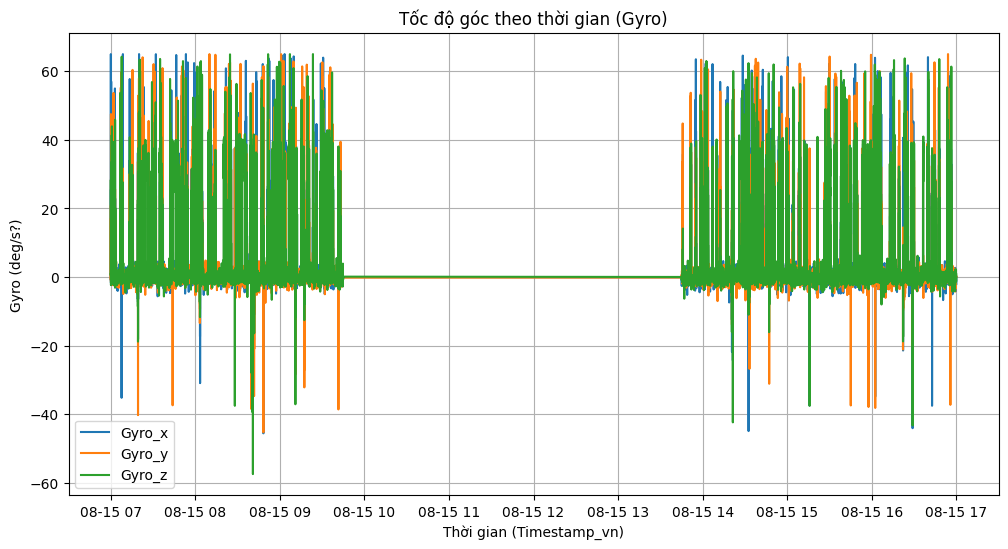

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["Gyro_x"], label="Gyro_x")
plt.plot(df.index, df["Gyro_y"], label="Gyro_y")
plt.plot(df.index, df["Gyro_z"], label="Gyro_z")
plt.title("Tốc độ góc theo thời gian (Gyro)")
plt.xlabel("Thời gian (Timestamp_vn)")
plt.ylabel("Gyro (deg/s?)")
plt.legend()
plt.grid(True)
plt.show()


### Độ lớn vectorvector

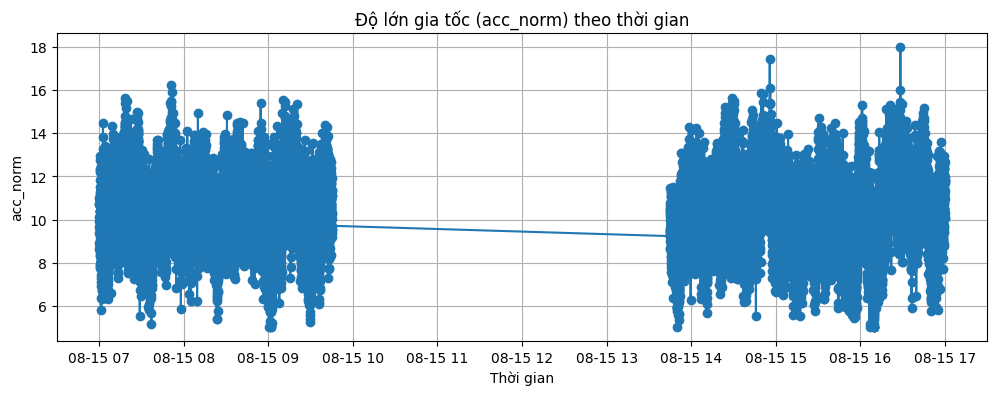

In [8]:
plt.figure(figsize=(12, 4))
plt.plot(df.index, df["acc_norm"], marker="o")
plt.title("Độ lớn gia tốc (acc_norm) theo thời gian")
plt.xlabel("Thời gian")
plt.ylabel("acc_norm")
plt.grid(True)
plt.show()


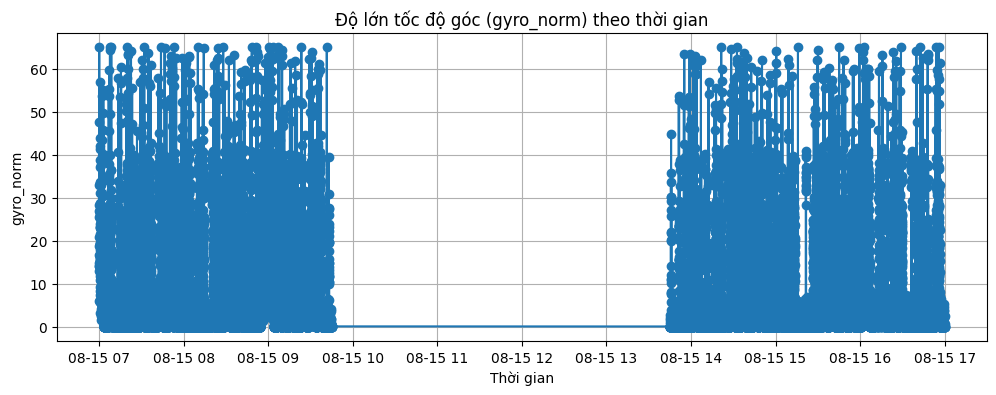

In [9]:
plt.figure(figsize=(12, 4))
plt.plot(df.index, df["gyro_norm"], marker="o")
plt.title("Độ lớn tốc độ góc (gyro_norm) theo thời gian")
plt.xlabel("Thời gian")
plt.ylabel("gyro_norm")
plt.grid(True)
plt.show()


### Xem phân bố

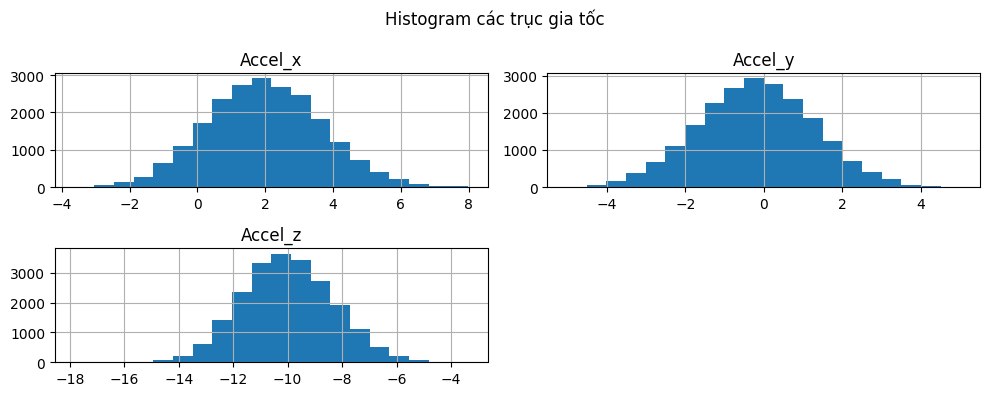

In [10]:
# Histogram cho Accel
df[["Accel_x", "Accel_y", "Accel_z"]].hist(bins=20, figsize=(10, 4))
plt.suptitle("Histogram các trục gia tốc")
plt.tight_layout()
plt.show()


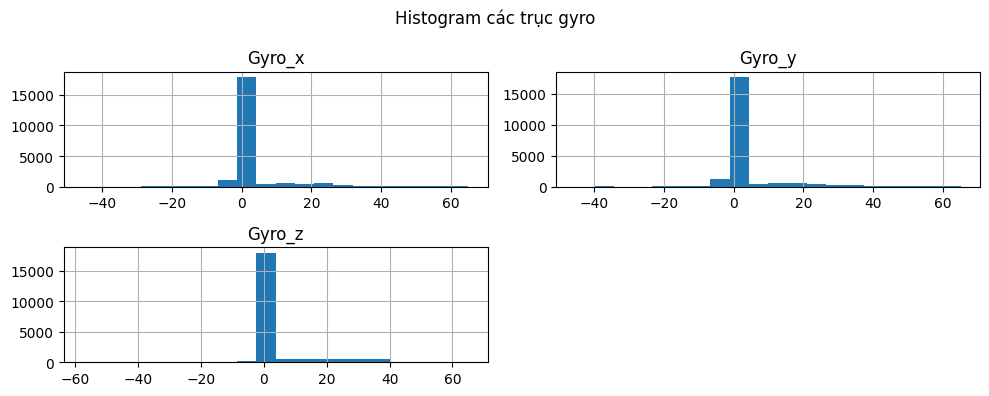

In [11]:
# Histogram cho Gyro
df[["Gyro_x", "Gyro_y", "Gyro_z"]].hist(bins=20, figsize=(10, 4))
plt.suptitle("Histogram các trục gyro")
plt.tight_layout()
plt.show()


/tmp/ipykernel_26932/1692526527.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df["acc_norm"], df["gyro_norm"]], labels=["acc_norm", "gyro_norm"])


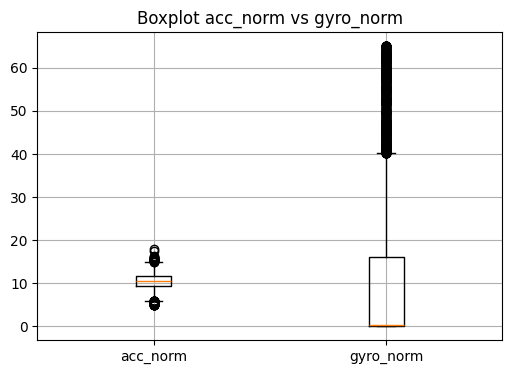

In [12]:
# Boxplot norm
plt.figure(figsize=(6, 4))
plt.boxplot([df["acc_norm"], df["gyro_norm"]], labels=["acc_norm", "gyro_norm"])
plt.title("Boxplot acc_norm vs gyro_norm")
plt.grid(True)
plt.show()
